# Import Modules

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import glob
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


# Data Loading and Hybrid Feature Extraction

In [2]:
def extract_hybrid_features(file_path, max_pad_len=128):
    # Load audio
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    # Normalize audio
    y = librosa.util.normalize(y)

    # 1. MFCC - 20
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    # Delta MFCC - 20
    mfcc_delta = librosa.feature.delta(mfcc)

    # Delta-Delta MFCC - 20
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # 2. Chroma - 12
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # 3. RMS Energy - 1
    rms = librosa.feature.rms(y=y)

    # 4. Spectral Features - 3
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    # 5. Zero Crossing Rate - 1
    zcr = librosa.feature.zero_crossing_rate(y)

    # Combine All Features - 77
    combined = np.vstack([
        mfcc,
        mfcc_delta,
        mfcc_delta2,
        chroma,
        rms,
        centroid,
        bandwidth,
        rolloff,
        zcr
    ])

    # Padding / Truncation
    if combined.shape[1] < max_pad_len:
        pad_width = max_pad_len - combined.shape[1]
        combined = np.pad(combined, ((0,0),(0,pad_width)), mode='constant')
    else:
        combined = combined[:, :max_pad_len]

    return combined.T
    
# Full RAVDESS emotion mapping
EMOTION_MAP = {'01':'neutral', '02':'calm', '03':'happy', '04':'sad', 
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

def load_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "Actor_*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} files...")

    for file in file_list:
        emotion = EMOTION_MAP[os.path.basename(file).split('-')[2]]
        X.append(extract_hybrid_features(file))
        y.append(emotion)
            
    return np.array(X), np.array(y)


In [3]:
DATA_PATH = r"C:\Users\asus\OneDrive\Desktop\Projects\Speech_Emotion_Recognition_LSTM_RAVDESS\RAVDESS"
X_raw, y_raw = load_data(DATA_PATH)

# Scaling: We flatten to scale, then reshape back to (N, 128, 77)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.reshape(-1, X_raw.shape[-1])).reshape(X_raw.shape)

lb = LabelEncoder()
y_final = to_categorical(lb.fit_transform(y_raw))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_final, test_size=0.2, random_state=42)

print(f"Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")

Extracting hybrid features from 1440 files...
Data loaded: X_train shape (1152, 128, 77), y_train shape (1152, 8)


# Create the Hybrid BiLSTM Model

In [4]:
model = Sequential([
    # Stage 1: Convolutional layers for local spectral patterns
    Conv1D(256, 5, padding='same', activation='relu', input_shape=(128, 77)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    # Stage 2: Recurrent layers for temporal emotional rhythm
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    Bidirectional(LSTM(64)),
    Dropout(0.3),

    # Stage 3: Classification head
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(8, activation='softmax')
])

# Training Configuration
opt = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# Callbacks to maximize accuracy and prevent overfitting
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)


In [5]:
# Training the Model
print("Starting training...")
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[reduce_lr, early_stop])


Starting training...
Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 393ms/step - accuracy: 0.1788 - loss: 2.5733 - val_accuracy: 0.2222 - val_loss: 2.0283 - learning_rate: 5.0000e-04
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 287ms/step - accuracy: 0.2847 - loss: 2.1109 - val_accuracy: 0.2986 - val_loss: 1.9104 - learning_rate: 5.0000e-04
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 321ms/step - accuracy: 0.3802 - loss: 1.8260 - val_accuracy: 0.3924 - val_loss: 1.7389 - learning_rate: 5.0000e-04
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.4601 - loss: 1.5390 - val_accuracy: 0.4201 - val_loss: 1.6294 - learning_rate: 5.0000e-04
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 308ms/step - accuracy: 0.5382 - loss: 1.3242 - val_accuracy: 0.4931 - val_loss: 1.4834 - learning_rate: 5.0000e-04
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.6380 - loss: 1.0234 - val_accuracy: 0.5729 - val_loss: 1.2452 - learning_rate: 5.0000e-04
Epoch 7/200
36/36 ━━━━━━━━━━━━━

In [6]:
# Evaluating the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

print(f"Best Train Accuracy: {max(history.history['accuracy']) * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8264 - loss: 0.7988
Test Accuracy: 82.64%
Test Loss: 0.7988
Best Train Accuracy: 100.00%


# Plot the Results

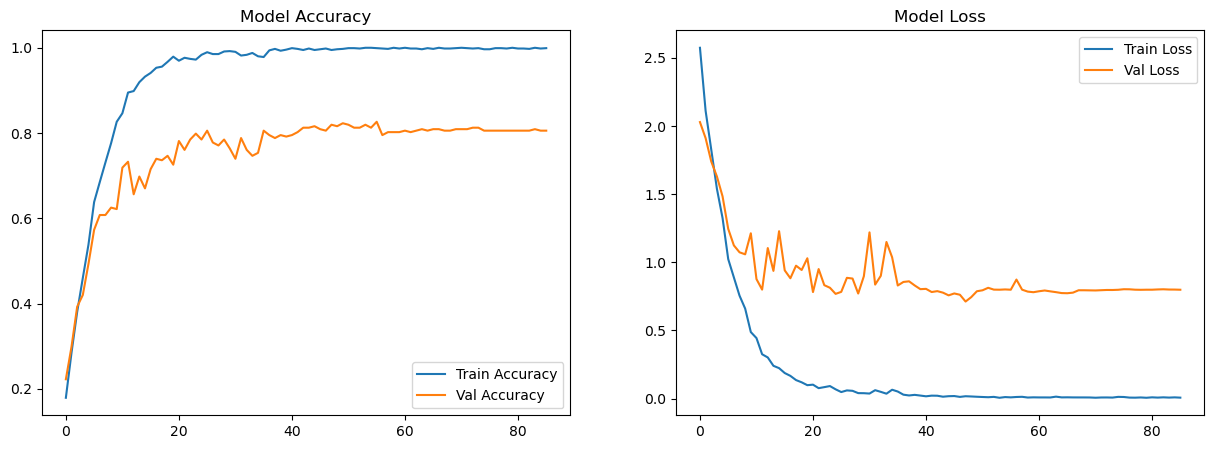

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


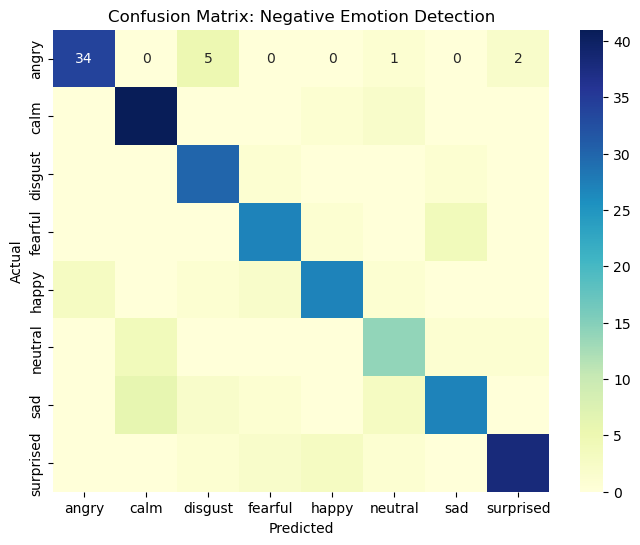


Classification Report:

              precision    recall  f1-score   support

       angry       0.92      0.81      0.86        42
        calm       0.80      0.93      0.86        44
     disgust       0.77      0.94      0.85        32
     fearful       0.82      0.84      0.83        32
       happy       0.84      0.79      0.82        34
     neutral       0.64      0.70      0.67        20
         sad       0.82      0.69      0.75        39
   surprised       0.93      0.84      0.88        45

    accuracy                           0.83       288
   macro avg       0.82      0.82      0.81       288
weighted avg       0.83      0.83      0.83       288



In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=lb.classes_, yticklabels=lb.classes_, cmap='YlGnBu')
plt.title('Confusion Matrix: Negative Emotion Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))
